

```
# EXERCICE:1 ###**bold text**:

```



In [1]:

X = [[0,0],[0,1],[1,0],[1,1]]
y_and = [0,0,0,1]
y_or = [0,1,1,1]
##FROM SCRATCH
import numpy as np
class Perceptron:
  def __init__(self,lr=0.5,epochs=10):
    self.lr=lr
    self.epochs=epochs

  def fit(self,X,y):
    self.w=np.zeros(len(X[0]))
    self.b=0

    for _ in range(self.epochs):
      for xi,target in zip(X,y):
        z=np.dot(xi,self.w)+self.b
        y_pred=1 if z>=0 else 0

        update =self.lr*(target-y_pred)
        self.w += update*np.array(xi)
        self.b += update

  def predict(self,X):
    return [1 if np.dot(x,self.w)+self.b>=0 else 0 for x in X ]
# AND
p_and = Perceptron()
p_and.fit(X, y_and)
print("AND:", p_and.predict(X))
# OR
p_or = Perceptron()
p_or.fit(X, y_or)
print("OR:", p_or.predict(X))



AND: [0, 0, 0, 1]
OR: [0, 1, 1, 1]


In [2]:
### sickit learn
from sklearn.linear_model import Perceptron
##AND
p=Perceptron()
p.fit(X,y_and)
print("AND:",p.predict(X))
##OR
p=Perceptron()
p.fit(X,y_or)
print("OR:",p.predict(X))



AND: [0 0 0 1]
OR: [0 1 1 1]


In [3]:
### keras
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X=np.array(([0,0],[0,1],[1,0],[1,1]),dtype=float)
y_and=np.array([0,0,0,1],dtype=float)
y_or=np.array([0,1,1,1],dtype=float)

def creer_and_entrainer_perceptron(X,y,nom_porte):
  model=Sequential()
  model.add(Dense(1,input_dim=2,activation='sigmoid'))
  model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
  model.fit(X,y,epochs=100,verbose=0)
  return model

model_and=creer_and_entrainer_perceptron(X,y_and,'AND')
model_or=creer_and_entrainer_perceptron(X,y_or,'OR')

print("\n--- AND ---")
for x in X:
    proba = model_and.predict(x.reshape(1,2), verbose=0)
    print(f"{x} → {round(proba[0][0])}")

print("\n--- OR ---")
for x in X:
    proba = model_or.predict(x.reshape(1,2), verbose=0)
    print(f"{x} → {round(proba[0][0])}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- AND ---
[0. 0.] → 0
[0. 1.] → 0
[1. 0.] → 0
[1. 1.] → 1

--- OR ---
[0. 0.] → 0
[0. 1.] → 1
[1. 0.] → 1
[1. 1.] → 1


EXERCICE:2


In [4]:
### EXERCICE:2 - Classification Iris Setosa ###

from urllib.request import urlopen

class Perceptron:
    def __init__(self, lr=0.5, epochs=10):
        self.lr = lr          # taux d'apprentissage
        self.epochs = epochs  # nombre de passages

    def fit(self, X, y):
        self.w = np.zeros(len(X[0]))  # initialisation des poids
        self.b = 0                     # biais

        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                # calcul de la prédiction
                z = np.dot(xi, self.w) + self.b
                y_pred = 1 if z >= 0 else 0

                # mise à jour des poids
                update = self.lr * (target - y_pred)
                self.w += update * np.array(xi)
                self.b += update

    def predict(self, X):
        return [1 if np.dot(x, self.w) + self.b >= 0 else 0 for x in X]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
data = np.genfromtxt(urlopen(url), delimiter=',', dtype='str')

X = data[:, [2, 3]].astype(float)  # indices 2 et 3 = longueur/largeur pétales
# y = 1 si Setosa, 0 sinon
y = np.where(data[:, 4] == "Iris-setosa", 1, 0)

print(f"Forme des donnees: {X.shape}")
print(f"Nombre de Setosa: {sum(y)}")
print(f"Nombre d'autres: {len(y)-sum(y)}")

# Normalisation (standardisation)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Division entraînement (80%) / test (20%)
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(len(X) * 0.8)
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Entraînement: {len(X_train)} exemples, Test: {len(X_test)} exemples\n")





Forme des donnees: (150, 2)
Nombre de Setosa: 50
Nombre d'autres: 100
Entraînement: 120 exemples, Test: 30 exemples



In [5]:
### FROM SCRATCH
print(" 1. FROM SCRATCH ")
model_scratch = Perceptron(lr=0.5, epochs=50)
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
accuracy_scratch = np.mean(y_pred_scratch == y_test)
print(f"Precision: {accuracy_scratch:.2f} ({accuracy_scratch*100:.1f}%)")

 1. FROM SCRATCH 
Precision: 1.00 (100.0%)


In [6]:
### SCIKIT-LEARN
print("\n2. SCIKIT-LEARN ")
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score

model_sklearn = SklearnPerceptron(max_iter=50, eta0=0.5, random_state=42)
model_sklearn.fit(X_train, y_train)
y_pred_sklearn = model_sklearn.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Precision: {accuracy_sklearn:.2f} ({accuracy_sklearn*100:.1f}%)")


2. SCIKIT-LEARN 
Precision: 1.00 (100.0%)


In [7]:
### keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Conversion en float32 pour TensorFlow
X_train_keras = X_train.astype(np.float32)
X_test_keras = X_test.astype(np.float32)
y_train_keras = y_train.astype(np.float32)
y_test_keras = y_test.astype(np.float32)

model_keras = Sequential([
    Dense(1, input_dim=2, activation='sigmoid')  # 2 entrées, 1 sortie
])
model_keras.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model_keras.fit(X_train_keras, y_train_keras, epochs=100, verbose=0, batch_size=8)

loss, accuracy_keras = model_keras.evaluate(X_test_keras, y_test_keras, verbose=0)
print(f"Précision: {accuracy_keras:.2f} ({accuracy_keras*100:.1f}%)")

#  7. RÉSULTATS
print("\n" + "-"*40)
print(" RÉSUMÉ DES PRÉCISIONS:")
print("-"*40)
print(f"From Scratch : {accuracy_scratch:.2%}")
print(f"Scikit-learn : {accuracy_sklearn:.2%}")
print(f"Keras        : {accuracy_keras:.2%}")
print("-"*40)

print("\n COMMENTAIRE: Les 3 implémentations donnent d'excellents résultats")
print("   car Iris Setosa est très différente des autres espèces.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Précision: 1.00 (100.0%)

----------------------------------------
 RÉSUMÉ DES PRÉCISIONS:
----------------------------------------
From Scratch : 100.00%
Scikit-learn : 100.00%
Keras        : 100.00%
----------------------------------------

 COMMENTAIRE: Les 3 implémentations donnent d'excellents résultats
   car Iris Setosa est très différente des autres espèces.


EXERCICE:3


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ---------- 1. Création des données ----------
np.random.seed(42)
X_reg = np.random.rand(200, 1) * 10  # 200 points entre 0 et 10
y_reg = 2 * X_reg + 1 + np.random.randn(200, 1) * 0.5  # y = 2x + 1 + bruit

# Division train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Données: {len(X_reg)} points")
print(f"Relation théorique: y = 2x + 1")
print(f"Entraînement: {len(X_train_reg)} points, Test: {len(X_test_reg)} points")

Données: 200 points
Relation théorique: y = 2x + 1
Entraînement: 160 points, Test: 40 points


In [9]:
### sickitlearn
model_sklearn_reg = LinearRegression()
model_sklearn_reg.fit(X_train_reg, y_train_reg)
y_pred_sklearn_reg = model_sklearn_reg.predict(X_test_reg)

mse_sklearn_reg = mean_squared_error(y_test_reg, y_pred_sklearn_reg)
r2_sklearn_reg = r2_score(y_test_reg, y_pred_sklearn_reg)

print(f"Poids appris: w = {model_sklearn_reg.coef_[0][0]:.4f}, b = {model_sklearn_reg.intercept_[0]:.4f}")
print(f"MSE: {mse_sklearn_reg:.4f}")
print(f"R²: {r2_sklearn_reg:.4f}")

Poids appris: w = 2.0052, b = 1.0073
MSE: 0.2712
R²: 0.9919


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Poids appris: w = 2.0061, b = 1.0061
MSE: 0.2718
R²: 0.9919


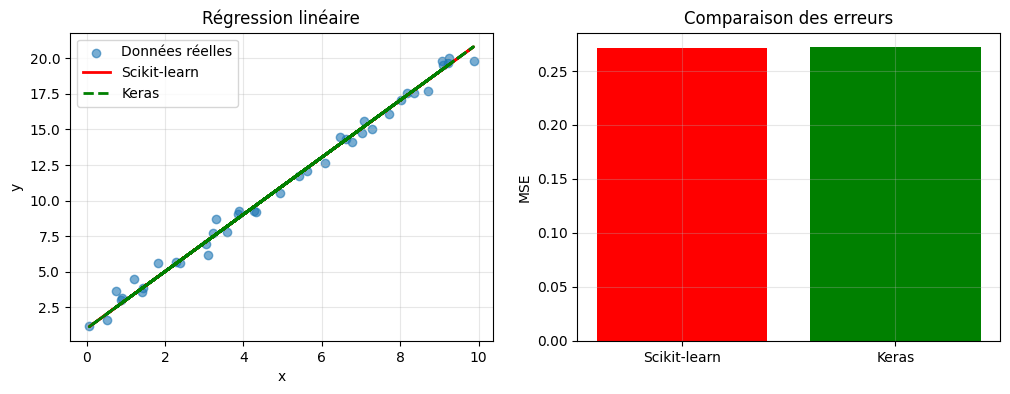

In [10]:
### keras
model_keras_reg = Sequential([
    Dense(1, input_dim=1, activation='linear')
])
model_keras_reg.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                        loss='mse')
model_keras_reg.fit(X_train_reg, y_train_reg, epochs=200, verbose=0, batch_size=16)
y_pred_keras_reg = model_keras_reg.predict(X_test_reg, verbose=0)

mse_keras_reg = mean_squared_error(y_test_reg, y_pred_keras_reg)
r2_keras_reg = r2_score(y_test_reg, y_pred_keras_reg)

w_keras_reg = model_keras_reg.layers[0].get_weights()[0][0][0]
b_keras_reg = model_keras_reg.layers[0].get_weights()[1][0]
print(f"Poids appris: w = {w_keras_reg:.4f}, b = {b_keras_reg:.4f}")
print(f"MSE: {mse_keras_reg:.4f}")
print(f"R²: {r2_keras_reg:.4f}")

# Visualisation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_test_reg, y_test_reg, alpha=0.6, label='Données réelles')
plt.plot(X_test_reg, y_pred_sklearn_reg, 'r-', linewidth=2, label='Scikit-learn')
plt.plot(X_test_reg, y_pred_keras_reg, 'g--', linewidth=2, label='Keras')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Régression linéaire')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['Scikit-learn', 'Keras'], [mse_sklearn_reg, mse_keras_reg], color=['red', 'green'])
plt.ylabel('MSE')
plt.title('Comparaison des erreurs')
plt.grid(True, alpha=0.3)
plt.show()

EXERCICE:4


In [11]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

# ---------- 1. Chargement des données ----------
digits = load_digits()
X_mnist = digits.data
y_mnist = digits.target

# Garder seulement 0 et 1
mask_mnist = (y_mnist == 0) | (y_mnist == 1)
X_mnist = X_mnist[mask_mnist]
y_mnist = y_mnist[mask_mnist]

print(f"Images: {X_mnist.shape[0]} (chiffres 0 et 1)")
print(f"Taille de chaque image: {X_mnist.shape[1]} pixels (8x8)")

# ---------- 2. Prétraitement ----------
scaler = StandardScaler()
X_mnist_scaled = scaler.fit_transform(X_mnist)

# Division train/test
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist_scaled, y_mnist, test_size=0.2, random_state=42
)

print(f"Entraînement: {len(X_train_mnist)} images")
print(f"Test: {len(X_test_mnist)} images")

Images: 360 (chiffres 0 et 1)
Taille de chaque image: 64 pixels (8x8)
Entraînement: 288 images
Test: 72 images


In [12]:
### sickit learn
model_sklearn_mnist = Perceptron(max_iter=100, eta0=0.01, random_state=42)
model_sklearn_mnist.fit(X_train_mnist, y_train_mnist)
y_pred_sklearn_mnist = model_sklearn_mnist.predict(X_test_mnist)

acc_sklearn_mnist = accuracy_score(y_test_mnist, y_pred_sklearn_mnist)
print(f"Précision: {acc_sklearn_mnist:.4f} ({acc_sklearn_mnist*100:.2f}%)")
print("\nRapport de classification:")
print(classification_report(y_test_mnist, y_pred_sklearn_mnist, target_names=['0', '1']))

Précision: 1.0000 (100.00%)

Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        37

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Précision: 1.0000 (100.00%)


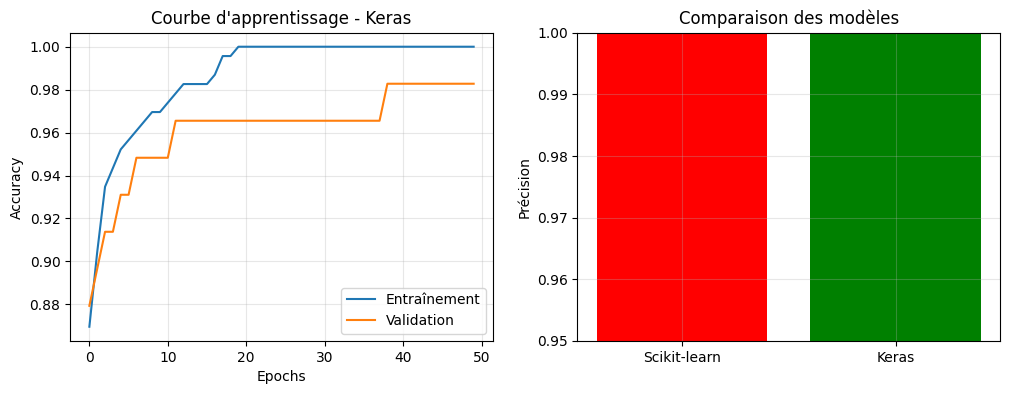

In [13]:
### keras
model_keras_mnist = Sequential([
    Dense(1, input_dim=X_mnist.shape[1], activation='sigmoid')
])
model_keras_mnist.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mnist = model_keras_mnist.fit(X_train_mnist, y_train_mnist,
                                       epochs=50, verbose=0, batch_size=16,
                                       validation_split=0.2)
loss, acc_keras_mnist = model_keras_mnist.evaluate(X_test_mnist, y_test_mnist, verbose=0)
print(f"Précision: {acc_keras_mnist:.4f} ({acc_keras_mnist*100:.2f}%)")

# Visualisation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'], label='Entraînement')
plt.plot(history_mnist.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Courbe d\'apprentissage - Keras')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['Scikit-learn', 'Keras'], [acc_sklearn_mnist, acc_keras_mnist], color=['red', 'green'])
plt.ylabel('Précision')
plt.title('Comparaison des modèles')
plt.ylim(0.95, 1.00)
plt.grid(True, alpha=0.3)
plt.show()

 EXERCICE:5

In [14]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------- 1. Génération des données ----------
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=3, n_features=2,
                                    cluster_std=1.5, random_state=42)
print(f"Données générées: {len(X_blobs)} points, 3 clusters")

# Standardisation
scaler_blob = StandardScaler()
X_blobs_scaled = scaler_blob.fit_transform(X_blobs)

# Pour le Perceptron (supervisé) - seulement clusters 0 et 1
mask_perc = y_blobs_true < 2
X_perc = X_blobs_scaled[mask_perc]
y_perc = y_blobs_true[mask_perc]

X_train_perc, X_test_perc, y_train_perc, y_test_perc = train_test_split(
    X_perc, y_perc, test_size=0.2, random_state=42
)
print(f"Perceptron (supervisé): {len(X_perc)} points (clusters 0 et 1)")

Données générées: 300 points, 3 clusters
Perceptron (supervisé): 200 points (clusters 0 et 1)


In [15]:
### sickitlearn
model_perc = Perceptron(max_iter=100, eta0=0.5, random_state=42)
model_perc.fit(X_train_perc, y_train_perc)
y_pred_perc = model_perc.predict(X_test_perc)
acc_perc = accuracy_score(y_test_perc, y_pred_perc)
print(f"Précision sur test: {acc_perc:.2%}")

Précision sur test: 100.00%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Précision: 100.00%

--- KMEANS (non supervisé, 3 clusters) ---
KMeans a regroupé en 3 clusters
Adjusted Rand Index (similarité avec vérité): 1.0000


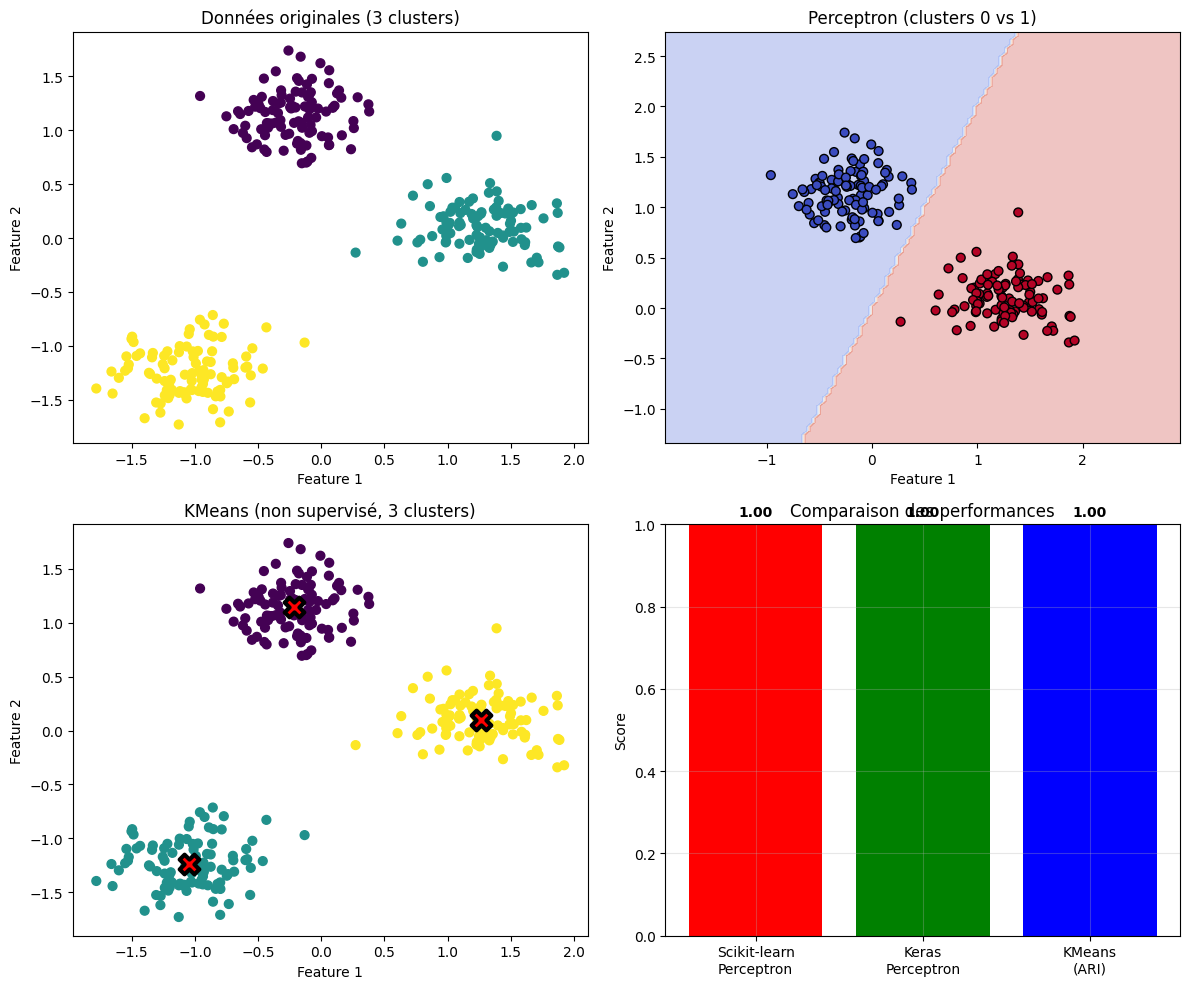

In [16]:
model_keras_perc = Sequential([
    Dense(1, input_dim=2, activation='sigmoid')
])
model_keras_perc.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model_keras_perc.fit(X_train_perc, y_train_perc, epochs=100, verbose=0, batch_size=8)
loss, acc_keras_perc = model_keras_perc.evaluate(X_test_perc, y_test_perc, verbose=0)
print(f"Précision: {acc_keras_perc:.2%}")

#  4. KMEANS (non supervisé)
print("\n--- KMEANS (non supervisé, 3 clusters) ---")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_blobs_scaled)

# Évaluation de KMeans (comparaison avec la vérité terrain)
from sklearn.metrics import adjusted_rand_score
ari_kmeans = adjusted_rand_score(y_blobs_true, y_kmeans)
print(f"KMeans a regroupé en 3 clusters")
print(f"Adjusted Rand Index (similarité avec vérité): {ari_kmeans:.4f}")

# 5. Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Données originales
axes[0, 0].scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1],
                   c=y_blobs_true, cmap='viridis', s=40)
axes[0, 0].set_title("Données originales (3 clusters)")
axes[0, 0].set_xlabel("Feature 1")
axes[0, 0].set_ylabel("Feature 2")

# Perceptron (frontière de décision)
xx, yy = np.meshgrid(np.linspace(X_perc[:,0].min()-1, X_perc[:,0].max()+1, 100),
                     np.linspace(X_perc[:,1].min()-1, X_perc[:,1].max()+1, 100))
Z = model_perc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
axes[0, 1].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
axes[0, 1].scatter(X_perc[:, 0], X_perc[:, 1], c=y_perc, cmap='coolwarm', s=40, edgecolors='black')
axes[0, 1].set_title("Perceptron (clusters 0 vs 1)")
axes[0, 1].set_xlabel("Feature 1")
axes[0, 1].set_ylabel("Feature 2")

# KMeans
axes[1, 0].scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=y_kmeans, cmap='viridis', s=40)
axes[1, 0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                   marker='X', c='red', s=200, linewidths=3, edgecolors='black')
axes[1, 0].set_title("KMeans (non supervisé, 3 clusters)")
axes[1, 0].set_xlabel("Feature 1")
axes[1, 0].set_ylabel("Feature 2")

# Comparaison des précisions
axes[1, 1].bar(['Scikit-learn\nPerceptron', 'Keras\nPerceptron', 'KMeans\n(ARI)'],
               [acc_perc, acc_keras_perc, ari_kmeans],
               color=['red', 'green', 'blue'])
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Comparaison des performances')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)
for i, v in enumerate([acc_perc, acc_keras_perc, ari_kmeans]):
    axes[1, 1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [17]:
# 6. Analyse des résultats
print("\n" + "="*60)
print(" ANALYSE DES RÉSULTATS ")
print("="*60)
print("\n PERCEPTRON (Scikit-learn & Keras):")
print("   - Type: Apprentissage SUPERVISÉ")
print("   - Nécessite des labels (y connu)")
print(f"   - Précision: {acc_perc:.2%} (Scikit-learn), {acc_keras_perc:.2%} (Keras)")
print("   - Frontière de décision: LINÉAIRE (ligne droite)")
print("   - Utilisé quand on a des données labellisées")
print("\n KMEANS:")
print("   - Type: Apprentissage NON SUPERVISÉ")
print("   - Ne nécessite PAS de labels")
print(f"   - Similarité avec vérité terrain (ARI): {ari_kmeans:.2%}")
print("   - Découvre automatiquement des clusters")
print("   - Utilisé pour explorer/segmenter des données sans labels")
print("\n CONCLUSION:")
print("   - Perceptron: meilleur quand on a des labels (classification supervisée)")
print("   - KMeans: meilleur pour découvrir des groupes naturels (clustering)")
print("   - Les deux méthodes sont complémentaires selon le problème")


 ANALYSE DES RÉSULTATS 

 PERCEPTRON (Scikit-learn & Keras):
   - Type: Apprentissage SUPERVISÉ
   - Nécessite des labels (y connu)
   - Précision: 100.00% (Scikit-learn), 100.00% (Keras)
   - Frontière de décision: LINÉAIRE (ligne droite)
   - Utilisé quand on a des données labellisées

 KMEANS:
   - Type: Apprentissage NON SUPERVISÉ
   - Ne nécessite PAS de labels
   - Similarité avec vérité terrain (ARI): 100.00%
   - Découvre automatiquement des clusters
   - Utilisé pour explorer/segmenter des données sans labels

 CONCLUSION:
   - Perceptron: meilleur quand on a des labels (classification supervisée)
   - KMeans: meilleur pour découvrir des groupes naturels (clustering)
   - Les deux méthodes sont complémentaires selon le problème
